# Scattering Properties of Cloud and Aerosol Particles Using Mie Code

## Install packages and load libraries

In [1]:
# !pip install miepython

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import miepython as mie

import warnings 
warnings.filterwarnings("ignore")   

## Simple test of Miepython

Document and Tutorial of miepython

https://miepython.readthedocs.io/en/latest/index.html


In [3]:
os.environ["MIEPYTHON_USE_JIT"] = "1"  # Must be set before importing

In [4]:
m = 1.5 - 1j       # Complex refractive index
d = 100            # Diameter (nm)
lambda0 = 314.15   # Wavelength in vacuum (nm)

# Calculate efficiencies
qext, qsca, qback, g = mie.efficiencies(m, d, lambda0)

print(f"Extinction efficiency:  {qext:.3f}")
print(f"Scattering efficiency:  {qsca:.3f}")
print(f"Backscatter efficiency: {qback:.3f}")
print(f"Scattering anisotropy:  {g:.3f}")

Extinction efficiency:  2.336
Scattering efficiency:  0.663
Backscatter efficiency: 0.573
Scattering anisotropy:  0.192


## Fetch Refractive index of water from online database
Read the water refractive index from the URL "https://refractiveindex.info/tmp/database/data/main/H2O/nk/Hale.txt", which contains two sections: one for wavelength and the real part of the refractive index, and another for wavelength and the imaginary part.

In [5]:
import requests

url = "https://refractiveindex.info/tmp/database/data/main/H2O/nk/Hale.txt"
response = requests.get(url)

if response.status_code == 200:
    file_content = response.text
    print("File content downloaded successfully.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

File content downloaded successfully.


In [6]:
lines = file_content.strip().split('\n')

separator_index = -1
for i, line in enumerate(lines):
    if line.startswith('---'):
        separator_index = i
        break

if separator_index != -1:
    section1_lines = [line for i, line in enumerate(lines) if i > 0 and i < separator_index and not line.startswith('#')]
    section2_lines = [line for i, line in enumerate(lines) if i > separator_index + 1 and not line.startswith('#')]
    print("Sections separated successfully.")
else:
    print("Separator '---' not found.")

Separator '---' not found.


In [7]:
lines = file_content.strip().split('\n')

separator_index = -1
for i, line in enumerate(lines):
    parts = line.split()
    if len(parts) != 2 or not parts[0].replace('.', '', 1).isdigit() or not parts[1].replace('.', '', 1).isdigit():
        # This line is not a data line with two numbers. It could be a header or the start of the next section.
        # If we've already passed the initial header (assuming the first line is a header), this is likely the separator.
        if i > 0:
            separator_index = i
            break

if separator_index != -1:
    # Assuming the first line is a header for the first section
    section1_lines = [line for i, line in enumerate(lines) if i > 0 and i < separator_index and not line.startswith('#')]
    # Assuming the line after the separator_index is a header for the second section
    section2_lines = [line for i, line in enumerate(lines) if i > separator_index + 1 and not line.startswith('#')]
    print(f"Sections separated successfully at line {separator_index}. Found {len(section1_lines)} lines for the first section and {len(section2_lines)} lines for the second section.")
else:
    # If no such line is found, it's possible the two sections are just appended.
    # In this case, we'll need to make an assumption about the number of lines in the first section,
    # or look for a pattern shift. Without a clear pattern shift or separator,
    # and based on the provided sample showing only 'n' data, it's difficult to definitively separate.
    # Since I cannot ask for help, I will assume for now that the entire content is the first section
    # and report that the separator was not found as expected. This is a failure to fully separate.
    section1_lines = [line for i, line in enumerate(lines) if i > 0 and not line.startswith('#')]
    section2_lines = []
    print("No clear separator found based on two-column numeric data. Assuming the entire content after the initial header belongs to the first section.")

Sections separated successfully at line 170. Found 169 lines for the first section and 169 lines for the second section.


### Extract data

#### Subtask:
Process each section to extract the wavelength and the corresponding real or imaginary part of the refractive index.


**Reasoning**:
Iterate through the lines of both `section1_lines` and `section2_lines`, extract and convert the wavelength and refractive index values to floats, and store them in separate lists as instructed.



In [8]:
wavelengths_n = []
n_values = []
for line in section1_lines:
    parts = line.split()
    if len(parts) == 2:
        try:
            wl = float(parts[0])
            n = float(parts[1])
            wavelengths_n.append(wl)
            n_values.append(n)
        except ValueError:
            # Skip lines that don't contain valid float pairs
            continue

wavelengths_k = []
k_values = []
for line in section2_lines:
    parts = line.split()
    if len(parts) == 2:
        try:
            wl = float(parts[0])
            k = float(parts[1])
            wavelengths_k.append(wl)
            k_values.append(k)
        except ValueError:
            # Skip lines that don't contain valid float pairs
            continue

print(f"Extracted {len(wavelengths_n)} wavelength and n values.")
print(f"Extracted {len(wavelengths_k)} wavelength and k values.")

Extracted 169 wavelength and n values.
Extracted 169 wavelength and k values.


### Organize data

#### Subtask:
Store the extracted data in a structured format, such as pandas DataFrames, for further analysis.


**Reasoning**:
Create pandas DataFrames from the extracted wavelength and refractive index values for both the real and imaginary parts.



In [9]:
# N = n+ik,   where k is absorption
df_n = pd.DataFrame({
    'Wavelength': wavelengths_n,
    'n': n_values
})

df_k = pd.DataFrame({
    'Wavelength': wavelengths_k,
    'k': k_values
})

display(df_n.head())
display(df_k.head())

,Wavelength,n
0,0.200,1.396
1,0.225,1.373
2,0.250,1.362
3,0.275,1.354
4,0.300,1.349


,Wavelength,k
0,0.200,1.100000e-07
1,0.225,4.900000e-08
2,0.250,3.350000e-08
3,0.275,2.350000e-08
4,0.300,1.600000e-08


In [10]:
df_merged = pd.merge(df_n, df_k, on='Wavelength')
display(df_merged.head())

,Wavelength,n,k
0,0.200,1.396,1.100000e-07
1,0.225,1.373,4.900000e-08
2,0.250,1.362,3.350000e-08
3,0.275,1.354,2.350000e-08
4,0.300,1.349,1.600000e-08


In [11]:
df_filtered = df_merged[(df_merged['Wavelength'] >= 0.2) & (df_merged['Wavelength'] <= 3.0)]
display(df_filtered.head())

,Wavelength,n,k
0,0.200,1.396,1.100000e-07
1,0.225,1.373,4.900000e-08
2,0.250,1.362,3.350000e-08
3,0.275,1.354,2.350000e-08
4,0.300,1.349,1.600000e-08


### Visualize data

#### Subtask:
Create a plot showing both the real ('n') and imaginary ('k') parts of the refractive index against wavelength.


**Reasoning**:
Create a figure with two subplots to plot the real and imaginary parts of the refractive index against wavelength, and then plot the data with appropriate labels and title.



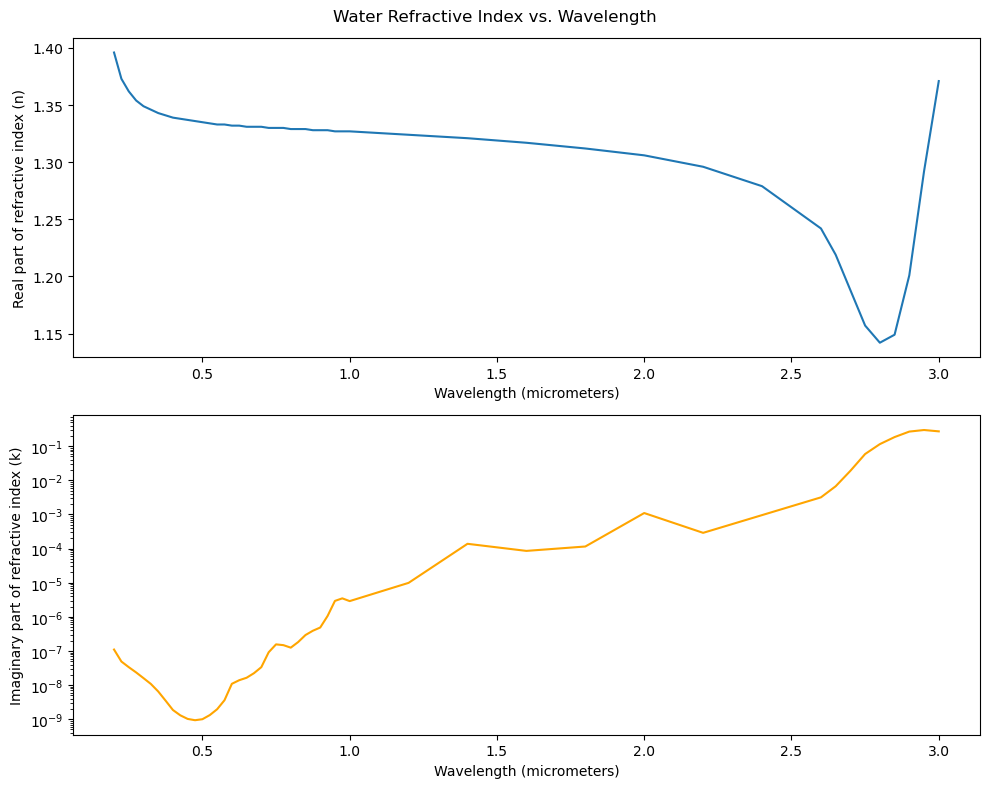

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(df_filtered['Wavelength'], df_filtered['n'])
ax1.set_xlabel('Wavelength (micrometers)')
ax1.set_ylabel('Real part of refractive index (n)')

ax2.plot(df_filtered['Wavelength'], df_filtered['k'], color='orange')
ax2.set_xlabel('Wavelength (micrometers)')
ax2.set_ylabel('Imaginary part of refractive index (k)')
ax2.set_yscale('log')

fig.suptitle('Water Refractive Index vs. Wavelength')
plt.tight_layout()
plt.show()

## Compute the Scattering properties of water droplet

In [13]:
Water_Ref = df_filtered
def Refractive_Index_Interp(Water_Ref,Wl_nm):
    """
    Interpolates the water refractive index (n + ik) for a given wavelength or array of wavelengths.

    Args:
        Wl: A single wavelength or a numpy array of wavelengths in micrometers.

    Returns:
        A complex number or a numpy array of complex numbers representing the
        interpolated refractive index at the given wavelength(s).
    """
    interp_n = np.interp(Wl_nm*1e-3, Water_Ref['Wavelength'], Water_Ref['n'])
    interp_k = np.interp(Wl_nm*1e-3, Water_Ref['Wavelength'], Water_Ref['k'])

    return interp_n - 1j * interp_k

In [14]:
Wl = np.array([470,550,670])
Ref = Refractive_Index_Interp(Water_Ref,Wl)
print(Ref)

[1.3362-9.520e-10j 1.333 -1.960e-09j 1.331 -2.112e-08j]


## Compute the scalar scattering properties: Qe, Qs, g-factor

In [15]:
Cloud_Scattering_Prop ={'R':{},'G':{},'B':{}}
wavelengths = [Wl[0], Wl[1], Wl[2]]
refs = [Ref[0], Ref[1], Ref[2]]
colors = ['B', 'G', 'R']

diameterRange = (100,300000)
nD = 500
d=np.logspace(np.log10(diameterRange[0]),np.log10(diameterRange[1]),nD)

for i, color in enumerate(colors):
    Cloud_Scattering_Prop[color]['Wl'] = wavelengths[i]
    Cloud_Scattering_Prop[color]['Ref'] = refs[i]

    qext, qsca, qback, g = mie.efficiencies(refs[i], d, wavelengths[i])

    Cloud_Scattering_Prop[color]['D'] =d
    Cloud_Scattering_Prop[color]['qext'] = qext
    Cloud_Scattering_Prop[color]['qsca'] = qsca
    Cloud_Scattering_Prop[color]['g'] = g

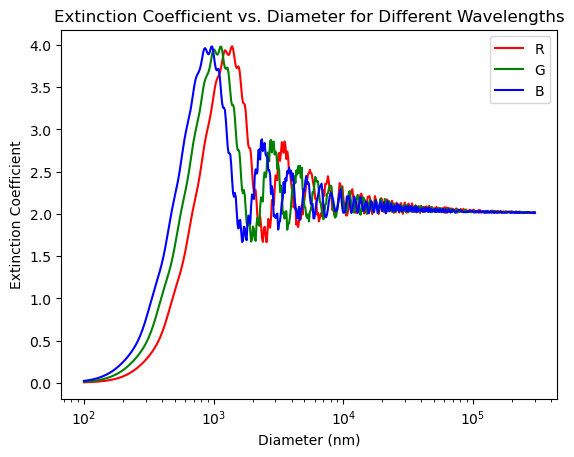

In [16]:
fig,ax=plt.subplots()
color_map = {'R': 'r', 'G': 'g', 'B': 'b'} # Create a dictionary to map colors
for color, data in Cloud_Scattering_Prop.items():
  ax.plot(data['D'],data['qext'],color=color_map[color],label=color) # Use the dictionary for color

ax.set_xscale('log')
ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Extinction Coefficient')
ax.set_title('Extinction Coefficient vs. Diameter for Different Wavelengths')
ax.legend()
plt.show()

## Compute phase matrix

In [17]:
Ang = np.arange(0, 180, 0.25)
Mu  = np.cos(np.radians(Ang))

In [18]:
for i, color in enumerate(colors):
    print('processing', color)
    Cloud_Scattering_Prop[color]['Ang'] = Ang
    Cloud_Scattering_Prop[color]['Mu'] = Mu
    # Initialize dictionaries to store matrix elements for each diameter
    Cloud_Scattering_Prop[color]['PhaseFunction'] = np.array([])
    Cloud_Scattering_Prop[color]['DoLP'] = np.array([])
    Cloud_Scattering_Prop[color]['Theta'] = np.array([])



    m = Cloud_Scattering_Prop[color]['Ref']
    for diameter in Cloud_Scattering_Prop[color]['D']:
        print('processing',diameter)
        x=np.pi*diameter/Cloud_Scattering_Prop[color]['Wl']
        # theta,Sl,Sr,Su= ps.ScatteringFunction(m, Cloud_Scattering_Prop[color]['Wl'], diameter, angularResolution=0.25, angleMeasure='degrees', normalization='t')

        S1, S2 = mie.S1_S2(m, x, Mu)
        S11 = (np.abs(S2) ** 2 + np.abs(S1) ** 2) / 2
        S12 = (np.abs(S2) ** 2 - np.abs(S1) ** 2) / 2
        Cloud_Scattering_Prop[color]['PhaseFunction']=np.append(Cloud_Scattering_Prop[color]['PhaseFunction'],np.array(S11))
        Cloud_Scattering_Prop[color]['DoLP']=np.append(Cloud_Scattering_Prop[color]['DoLP'],np.array(S12))
        #print('Su.max',Su.max())
        #print(Cloud_Scattering_Prop[color]['Theta'].shape)
        #print('max',Cloud_Scattering_Prop[color]['PhaseFunction'].max())


    Cloud_Scattering_Prop[color]['Theta']=np.array(Ang)
    Cloud_Scattering_Prop[color]['PhaseFunction']=np.reshape(Cloud_Scattering_Prop[color]['PhaseFunction'],(len(Cloud_Scattering_Prop[color]['D']),len(Ang)))
    Cloud_Scattering_Prop[color]['DoLP']=np.reshape(Cloud_Scattering_Prop[color]['DoLP'],(len(Cloud_Scattering_Prop[color]['D']),len(Ang)))

processing B
processing 100.0
processing 101.61742341766677
processing 103.26100742045372
processing 104.93117513579077
processing 106.6283565348701
processing 108.3529885433383
processing 110.10551515378005
processing 111.88638754001992
processing 113.69606417327361
processing 115.53501094017759
processing 117.403701262728
processing 119.30261622015891
processing 121.23224467279289
processing 123.19308338789372
processing 125.18563716755527
processing 127.21041897865868
processing 129.26795008493164
processing 131.35876018114314
processing 133.4833875294697
processing 135.64237909806621
processing 137.83629070187868
processing 140.06568714573413
processing 142.33114236974527
processing 144.63323959706617
processing 146.9725714840392
processing 149.34974027276908
processing 151.76535794616535
processing 154.22004638549245
processing 156.71443753046796
processing 159.24917354195068
processing 161.82490696725898
processing 164.44230090816492
processing 167.10202919160363
processing 169.8

In [19]:
Cloud_Scattering_Prop['B']['PhaseFunction'].shape
print(Cloud_Scattering_Prop['R']['PhaseFunction'].max())

79071.96871315701


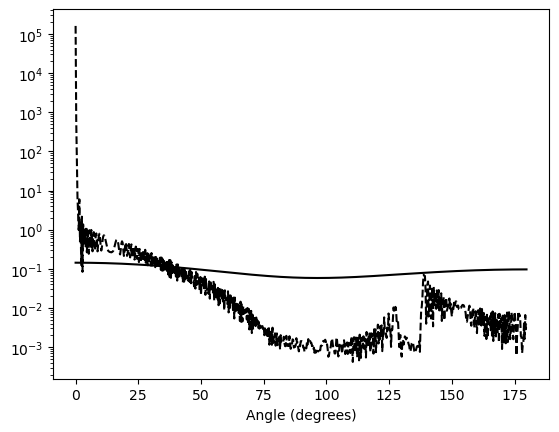

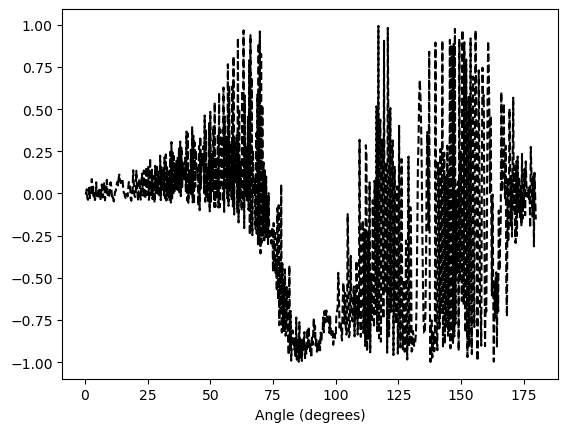

In [20]:
fig,ax=plt.subplots()
ax.plot(Cloud_Scattering_Prop['B']['Theta'],
        Cloud_Scattering_Prop['B']['PhaseFunction'][0,:],
        c='k',ls='solid')
ax.plot(Cloud_Scattering_Prop['B']['Theta'],
        Cloud_Scattering_Prop['B']['PhaseFunction'][-1,:],
        c='k',ls='dashed')
ax.set_yscale('log')
ax.set_xlabel('Angle (degrees)')
plt.show()


fig,ax=plt.subplots()
# ax.plot(Cloud_Scattering_Prop['B']['Theta'],
#         Cloud_Scattering_Prop['B']['DoLP'][0,:],
#         c='k',ls='solid')
ax.plot(Cloud_Scattering_Prop['B']['Theta'],
        Cloud_Scattering_Prop['B']['DoLP'][-1,:]/Cloud_Scattering_Prop['B']['PhaseFunction'][-1,:],
        c='k',ls='dashed')
#ax.set_yscale('log')
ax.set_xlabel('Angle (degrees)')
plt.show()

## Average Phase Function over Particle size distribution

In [21]:
def Gamma_PSD(r,N0,re,ve):
  '''
  Input:
  r: radius [micronmeter]
  N0: number density [cm^-3]
  re: particle radius [micronmeter]
  ve: particle effective variance [unitless]
  Output:
  dNdr: Particle size distribution [cm^-3 um^-1]
  '''
  exponent1 = (1-3*ve)/ve
  exponent2 = 1/ve/re
  PSD = np.power(r,exponent1)*np.exp(-exponent2*r) # Corrected np.exp call
  Norm = np.trapezoid(PSD,r)
  dNdr = N0*PSD/Norm
  return dNdr

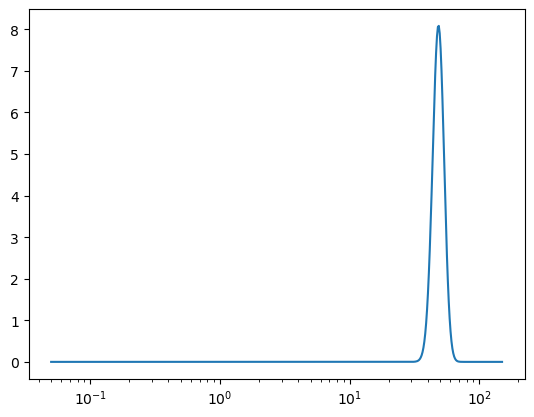

In [23]:
r = Cloud_Scattering_Prop['B']['D']/2/1000.0
re = 50.0
ve = 0.01
N0 = 100
dNdr = Gamma_PSD(r, N0, re, ve)

fig, ax = plt.subplots()
ax.plot(r, dNdr)
ax.set_xscale('log')

In [24]:
from re import U
P12 = []
P11 = []

for i in range(len(Cloud_Scattering_Prop['B']['Theta'])):
  p11 = Cloud_Scattering_Prop['B']['PhaseFunction'][:, i]
  p12 = Cloud_Scattering_Prop['B']['DoLP'][:, i]
  s = Cloud_Scattering_Prop['B']['qext']
  a = np.pi*Cloud_Scattering_Prop['B']['D']**2/4
  U1 = np.trapz(p11*s*a*dNdr, Cloud_Scattering_Prop['B']['D']/2)
  U2 = np.trapz(p12*s*a*dNdr, Cloud_Scattering_Prop['B']['D']/2)
  D = np.trapz(s*a*dNdr, Cloud_Scattering_Prop['B']['D']/2)
  P11.append(U1/D)
  P12.append(U2/D)

(0.1, 100)

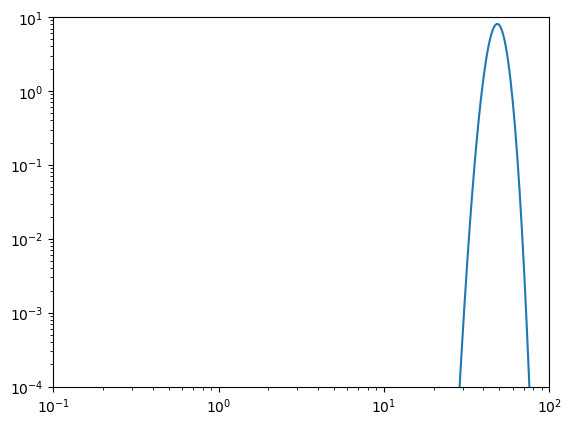

In [26]:
fig, ax = plt.subplots()
ax.plot(r, dNdr)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim([1e-4, 10])
ax.set_xlim([1e-1, 100])

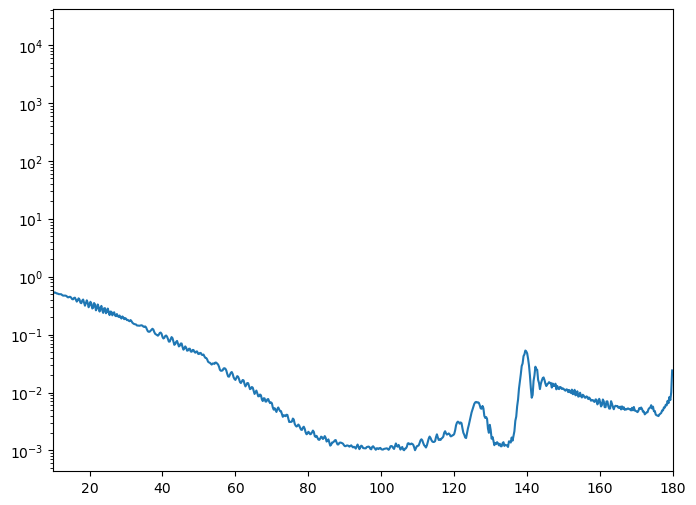

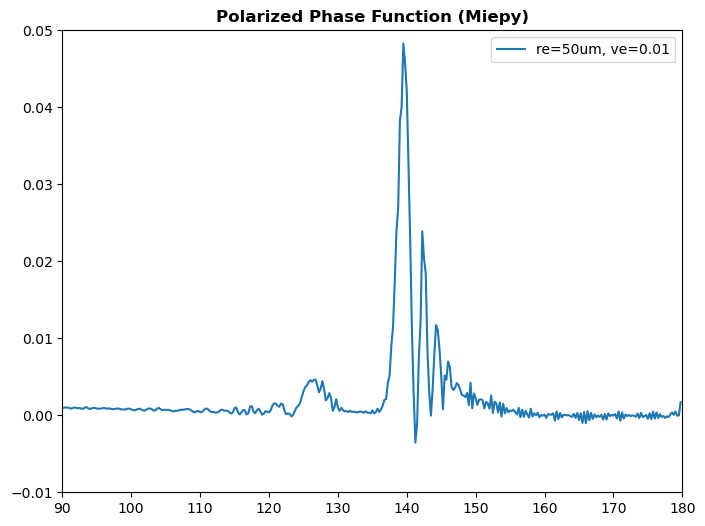

In [29]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(Cloud_Scattering_Prop['B']['Theta'], np.array(P11))
ax.set_xlim([10,180])
ax.set_yscale('log')

fig, ax = plt.subplots(figsize=(8,6))     
ax.plot(Cloud_Scattering_Prop['B']['Theta'], -np.array(P12), label='re=50um, ve=0.01')
ax.set_title('Polarized Phase Function (Miepy)', fontsize=12, color='k', fontweight='bold')
ax.set_xlim([90,180])
ax.set_ylim([-0.01,0.05])
#ax.set_yscale('log')
ax.legend()
# plt.savefig('Polarized PF (Miepy).png', dpi=500, bbox_inches="tight")